In [1]:
from primordialpy.background import Background
from primordialpy.model import PotentialFunction
from primordialpy.perturbations import  Perturbations
from primordialpy.pbhabundance import PBHAbundance
from primordialpy.pbhconstraints import PBHConstraints

import matplotlib.pyplot as plt

In [5]:

V = """
    V0 * (1 + a*(phi/sqrt(6))**2) * exp(4*phi/sqrt(6)) / 
    (1 + c*(1 + b*(phi/sqrt(6))) * exp(2*phi/sqrt(6)))**2
    """
params = {
        'V0': 1.0e-10,   # Ajustar para amplitud As ~ 2e-9
        'a':  2.3e-3,    # Relacionado con b_lambda
        'b':  1.9e-3,    # Relacionado con b_xi
        'c':  1.5,       # Relacionado con xi0
    }
potential = PotentialFunction.from_string(V, param_values=params)

In [6]:
#Instancia de la clase background
background = Background(potential, phi0 = 6.2) 
sol = background.solver()

In [7]:
#Extrayendo datos de la clase background

vars = ['N', 'phi', 'dphidN', 'H', 'a', 'aH', 'eps_H', 'eta_H']
N, phi, dphidN, H, a, aH, eps_H, eta_H = (background.data(save=True)[i] for i in vars)

Figure saved as: Figures/potential.pdf


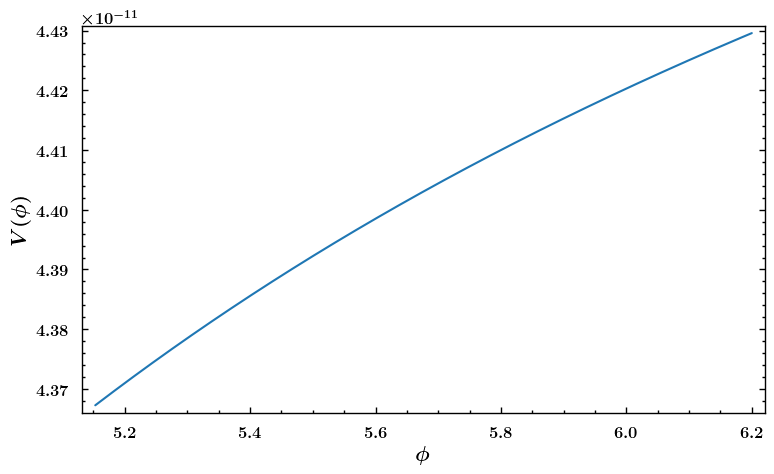

In [8]:
potential.plot_potential(min(phi), max(phi), dpi= 100, save = True)


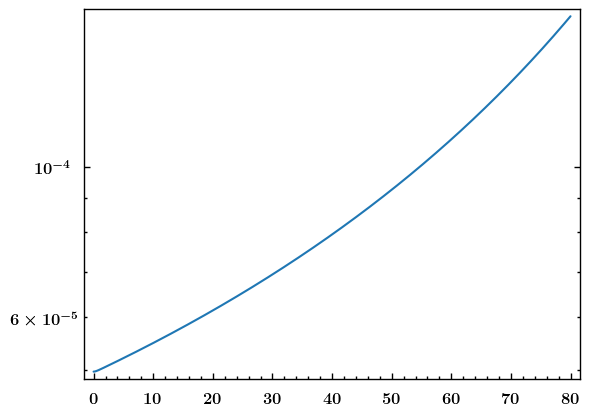

In [9]:
plt.semilogy(N, eps_H)